<a href="https://colab.research.google.com/github/vardhamanadarsh/PLFS_Data_Unemployment_2025/blob/main/PLFS_unemployment_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_excel('plfs_39.xlsx')
df

,year_type,year,frequency,indicator,state,gender,sector,AgeGroup,weekly_status,religion,socialGroup,General_Education,quarter,month,employee_contract,value,unit
0,Calendar Year,2022,Annually,"UR (Unemployment Rate, in per cent)",All India,male,rural,15-29 years,PS+SS,all,all,all,NaN,NaN,NaN,9.1,%
1,Calendar Year,2022,Annually,"UR (Unemployment Rate, in per cent)",All India,male,rural,15 years and above,CWS,all,all,all,NaN,NaN,NaN,5.2,%
2,Calendar Year,2022,Annually,"UR (Unemployment Rate, in per cent)",All India,male,rural,15 years and above,PS+SS,all,all,all,NaN,NaN,NaN,3.1,%
3,Calendar Year,2022,Annually,"UR (Unemployment Rate, in per cent)",All India,male,rural,15 years and above,PS+SS,all,scheduled tribe,all,NaN,NaN,NaN,1.9,%
4,Calendar Year,2022,Annually,"UR (Unemployment Rate, in per cent)",All India,male,rural,15 years and above,PS+SS,all,scheduled caste,all,NaN,NaN,NaN,3.4,%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19219,Calendar Year,2025,Annually,"UR (Unemployment Rate, in per cent)",West Bengal,person,rural + urban,All ages,PS+SS,all,all,5.higher secondary,NaN,NaN,NaN,6.4,%
19220,Calendar Year,2025,Annually,"UR (Unemployment Rate, in per cent)",West Bengal,person,rural + urban,All ages,PS+SS,all,all,6.diploma/ certificate course,NaN,NaN,NaN,11.6,%
19221,Calendar Year,2025,Annually,"UR (Unemployment Rate, in per cent)",West Bengal,person,rural + urban,All ages,PS+SS,all,all,7.graduate,NaN,NaN,NaN,11.4,%
19222,Calendar Year,2025,Annually,"UR (Unemployment Rate, in per cent)",West Bengal,person,rural + urban,All ages,PS+SS,all,all,8.post graduate & above,NaN,NaN,NaN,6.3,%


/tmp/ipykernel_880/731981380.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_880/731981380.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


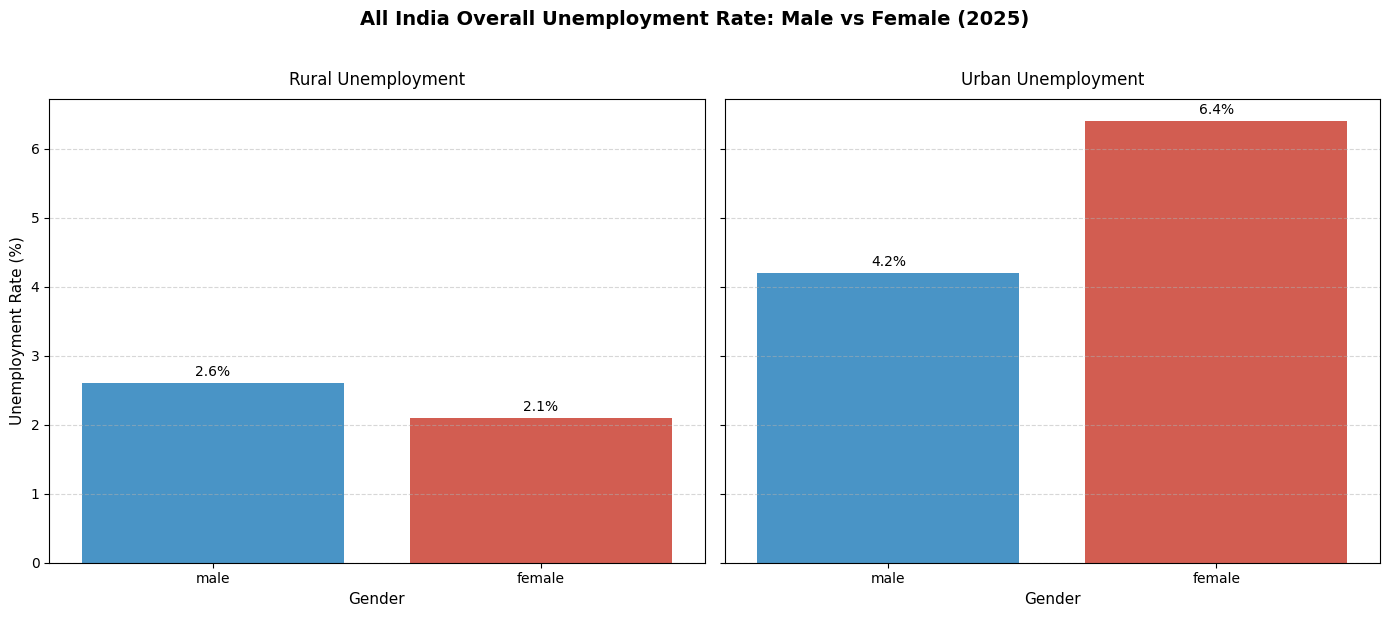

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic string cleaning to handle hidden spaces
df['state'] = df['state'].astype(str).str.strip()
df['AgeGroup'] = df['AgeGroup'].astype(str).str.strip()
df['gender'] = df['gender'].astype(str).str.strip()
df['sector'] = df['sector'].astype(str).str.strip()

# 2. Filter for Overall All-India, Usual Status (PS+SS) trends
filtered_df = df[
    (df['state'] == 'All India') &
    (df['AgeGroup'] == 'All ages') &
    (df['gender'].isin(['male', 'female'])) &
    (df['sector'].isin(['rural', 'urban'])) &
    (df['religion'] == 'all') &
    (df['socialGroup'] == 'all') &
    (df['General_Education'] == 'all') &
    (df['weekly_status'] == 'PS+SS')
]

# 3. Use the most recent year present in your dataset
latest_year = filtered_df['year'].max()
plot_data = filtered_df[filtered_df['year'] == latest_year]

# 4. Set up a 1-row, 2-column subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Subplot 1: Rural Sector ---
sns.barplot(
    data=plot_data[plot_data['sector'] == 'rural'],
    x='gender',
    y='value',
    palette=['#3498db', '#e74c3c'],  # Blue for male, Red for female
    ax=axes[0]
)
axes[0].set_title('Rural Unemployment', fontsize=12, pad=10)
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Unemployment Rate (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Add exact value labels on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# --- Subplot 2: Urban Sector ---
sns.barplot(
    data=plot_data[plot_data['sector'] == 'urban'],
    x='gender',
    y='value',
    palette=['#3498db', '#e74c3c'],
    ax=axes[1]
)
axes[1].set_title('Urban Unemployment', fontsize=12, pad=10)
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('')  # Cleared since sharey=True shares the left axis label
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Add exact value labels on top of the bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)

# 5. Global polishing and render
plt.suptitle(f'All India Overall Unemployment Rate: Male vs Female ({latest_year})', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_880/1095763653.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


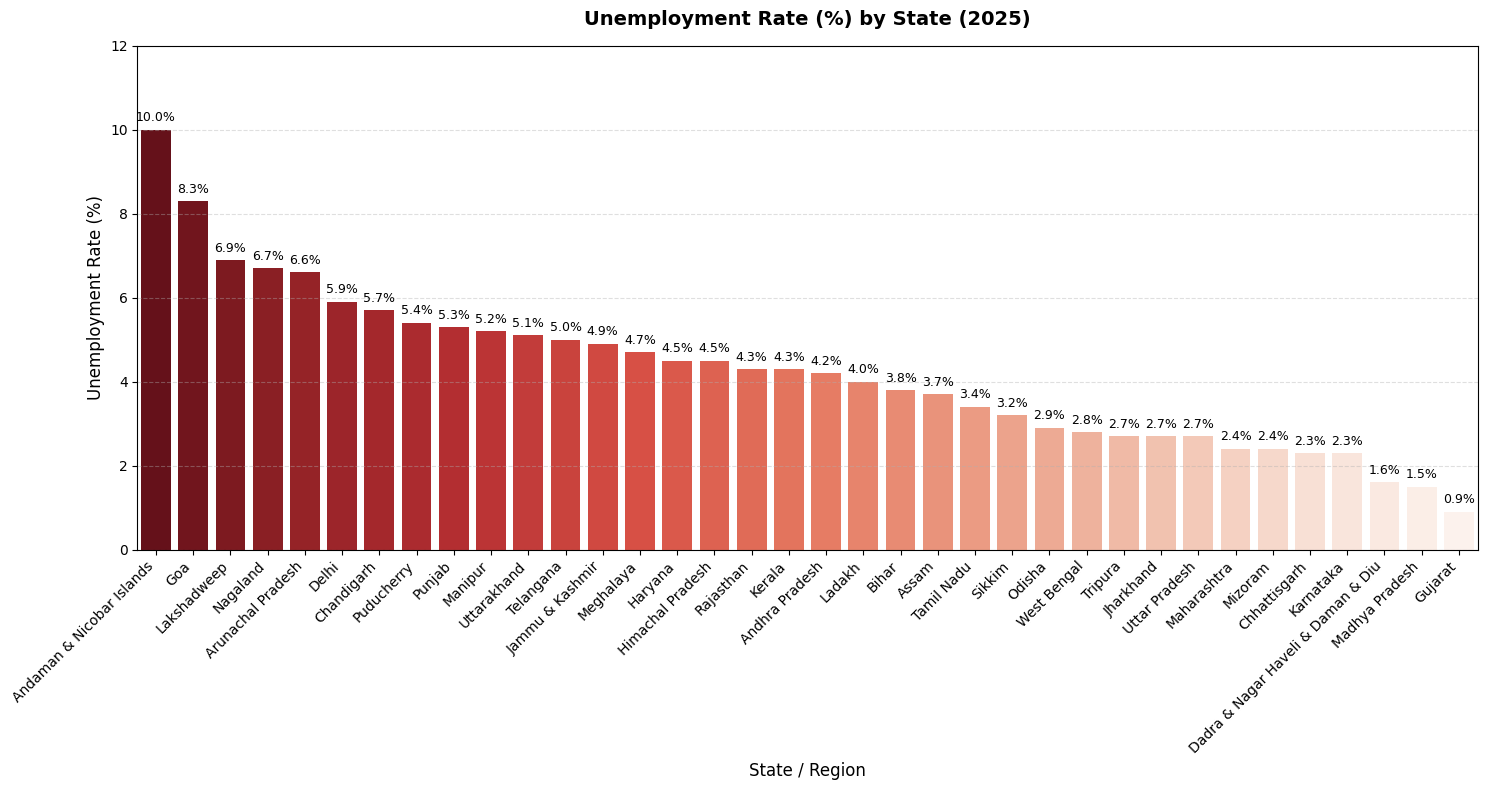

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean text fields to remove any accidental spaces
df['state'] = df['state'].astype(str).str.strip()
df['AgeGroup'] = df['AgeGroup'].astype(str).str.strip()
df['gender'] = df['gender'].astype(str).str.strip()
df['sector'] = df['sector'].astype(str).str.strip()

# 2. Filter for overall population data (person, combined sectors, all ages)
filtered_df = df[
    (df['state'] != 'All India') &           # Remove national total to see only state comparisons
    (df['gender'] == 'person') &
    (df['sector'] == 'rural + urban') &
    (df['AgeGroup'] == 'All ages') &
    (df['religion'] == 'all') &
    (df['socialGroup'] == 'all') &
    (df['General_Education'] == 'all') &
    (df['weekly_status'] == 'PS+SS')
]

# 3. Get the latest year and sort states by unemployment value
latest_year = filtered_df['year'].max()
plot_data = filtered_df[filtered_df['year'] == latest_year].copy()
plot_data = plot_data.sort_values(by='value', ascending=False) # Rank highest to lowest

# 4. Create a ranked bar plot
plt.figure(figsize=(15, 8))
sns.barplot(
    data=plot_data,
    x='state',
    y='value',
    palette='Reds_r' # Deep red for high unemployment, fading to light orange
)

# 5. Add text values on top of every bar
for index, row in enumerate(plot_data.itertuples()):
    plt.text(index, row.value + 0.2, f'{row.value:.1f}%', color='black', ha="center", fontsize=9)

# 6. Final chart adjustments
plt.title(f'Unemployment Rate (%) by State ({latest_year})', fontsize=14, pad=15, weight='bold')
plt.xlabel('State / Region', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, plot_data['value'].max() + 2) # Leave space at the top for labels
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

/tmp/ipykernel_880/1687100093.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_880/1687100093.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


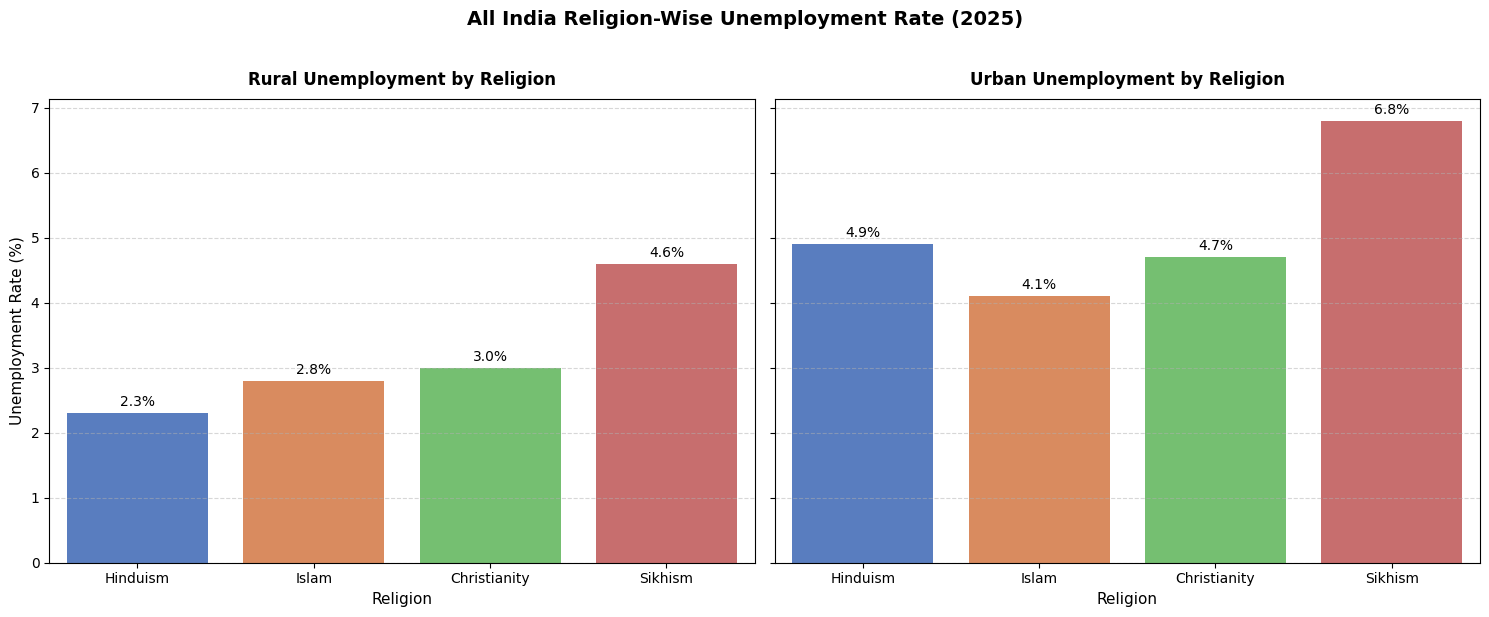

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean string columns to eliminate trailing whitespaces
df['religion'] = df['religion'].astype(str).str.strip()
df['state'] = df['state'].astype(str).str.strip()
df['sector'] = df['sector'].astype(str).str.strip()
df['gender'] = df['gender'].astype(str).str.strip()
df['AgeGroup'] = df['AgeGroup'].astype(str).str.strip()

# 2. Define the core religious groups to avoid plotting 'all' or 'others'
target_religions = ['Hinduism', 'Islam', 'Christianity', 'Sikhism']

# 3. Filter for overall population categories (person, all ages, usual status)
filtered_df = df[
    (df['state'] == 'All India') &
    (df['religion'].isin(target_religions)) &
    (df['sector'].isin(['rural', 'urban'])) &
    (df['gender'] == 'person') &
    (df['AgeGroup'] == 'All ages') &
    (df['socialGroup'] == 'all') &
    (df['General_Education'] == 'all') &
    (df['weekly_status'] == 'PS+SS')
]

# 4. Grab the latest year from your dataframe slice
latest_year = filtered_df['year'].max()
plot_data = filtered_df[filtered_df['year'] == latest_year]

# 5. Build side-by-side subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Left Chart: Rural Sector ---
sns.barplot(
    data=plot_data[plot_data['sector'] == 'rural'],
    x='religion',
    y='value',
    palette='muted',
    ax=axes[0]
)
axes[0].set_title('Rural Unemployment by Religion', fontsize=12, pad=10, weight='bold')
axes[0].set_xlabel('Religion', fontsize=11)
axes[0].set_ylabel('Unemployment Rate (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Append exact numbers above the bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# --- Right Chart: Urban Sector ---
sns.barplot(
    data=plot_data[plot_data['sector'] == 'urban'],
    x='religion',
    y='value',
    palette='muted',
    ax=axes[1]
)
axes[1].set_title('Urban Unemployment by Religion', fontsize=12, pad=10, weight='bold')
axes[1].set_xlabel('Religion', fontsize=11)
axes[1].set_ylabel('') # Hidden since sharey=True links the axis scales
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Append exact numbers above the bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)

# 6. Global formatting and presentation
plt.suptitle(f'All India Religion-Wise Unemployment Rate ({latest_year})', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_880/269381352.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_880/269381352.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


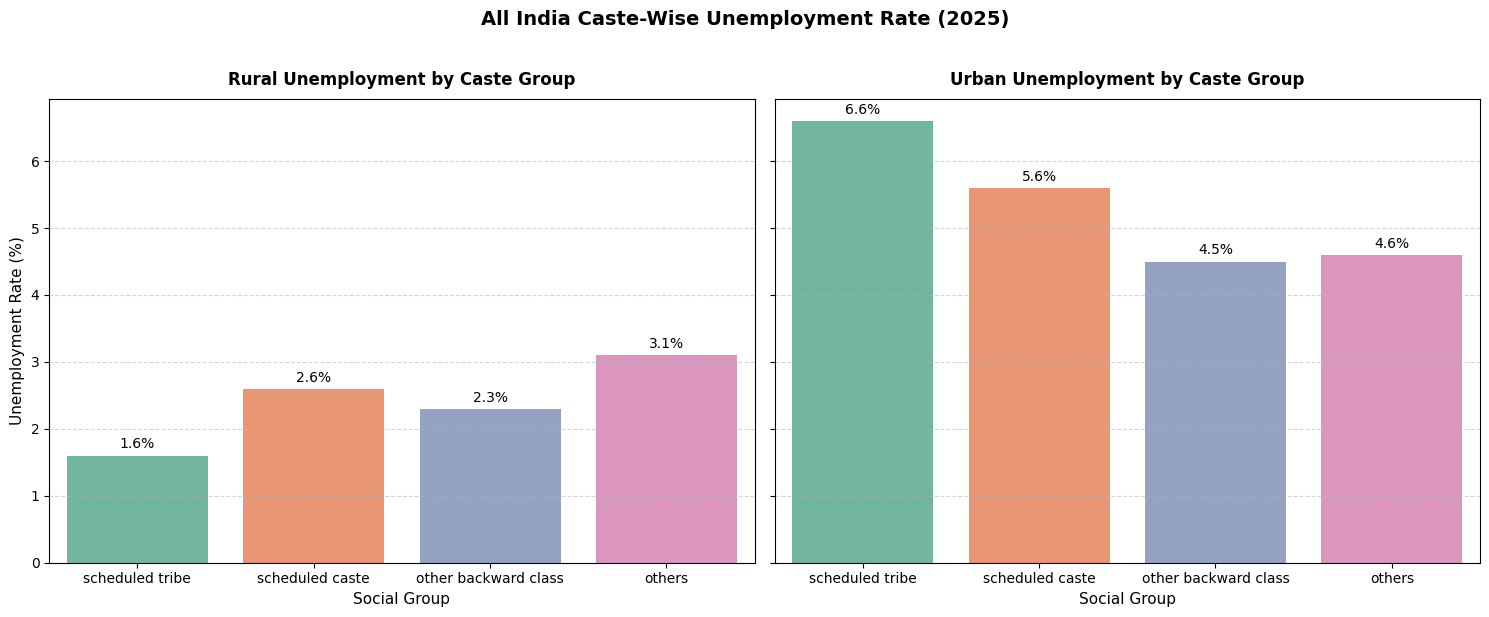

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean string spacing
df['state'] = df['state'].astype(str).str.strip()
df['sector'] = df['sector'].astype(str).str.strip()
df['gender'] = df['gender'].astype(str).str.strip()
df['AgeGroup'] = df['AgeGroup'].astype(str).str.strip()
df['weekly_status'] = df['weekly_status'].astype(str).str.strip()

# 2. Automatically find available caste groups while ignoring the aggregate 'all'
all_social_groups = df['socialGroup'].astype(str).str.strip().unique()
target_groups = [g for g in all_social_groups if g.lower() != 'all']

# 3. Filter baseline constraints (leaving socialGroup dynamic)
filtered_df = df[
    (df['state'] == 'All India') &
    (df['sector'].isin(['rural', 'urban'])) &
    (df['gender'] == 'person') &
    (df['AgeGroup'] == 'All ages') &
    (df['religion'] == 'all') &
    (df['General_Education'] == 'all') &
    (df['weekly_status'] == 'PS+SS') &
    (df['socialGroup'].astype(str).str.strip().isin(target_groups))
]

# 4. Grab the latest valid year data
latest_year = filtered_df['year'].max()
plot_data = filtered_df[filtered_df['year'] == latest_year]

# 5. Build side-by-side subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Left Chart: Rural Sector ---
sns.barplot(
    data=plot_data[plot_data['sector'] == 'rural'],
    x='socialGroup',
    y='value',
    palette='Set2',
    ax=axes[0]  # Expressly specified left subplot array index
)
axes[0].set_title('Rural Unemployment by Caste Group', fontsize=12, pad=10, weight='bold')
axes[0].set_xlabel('Social Group', fontsize=11)
axes[0].set_ylabel('Unemployment Rate (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# --- Right Chart: Urban Sector ---
sns.barplot(
    data=plot_data[plot_data['sector'] == 'urban'],
    x='socialGroup',
    y='value',
    palette='Set2',
    ax=axes[1]  # Expressly specified right subplot array index
)
axes[1].set_title('Urban Unemployment by Caste Group', fontsize=12, pad=10, weight='bold')
axes[1].set_xlabel('Social Group', fontsize=11)
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)

# 6. Global formatting and presentation
plt.suptitle(f'All India Caste-Wise Unemployment Rate ({latest_year})', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()
